In [127]:
import os, sys, pickle
%pylab inline
from importlib import reload
import pandas as pd
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 3)
from tqdm import tqdm
from copy import deepcopy
import pickle
from collections import Counter

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [85]:
git_path = os.getenv("GIT")
proj_path = os.path.join(git_path, "glom-io-transform-release")
sys.path.append(proj_path)
os.chdir(proj_path + "/model-fitting")
os.getcwd()
os.environ["GLOM_IO"] = proj_path
os.environ["GLOM_IO_DATA"] = proj_path + "/data"

In [114]:
from odours import odours

In [86]:
import driver; reload(driver)
from driver import RunResults

In [155]:
import results; reload(results)

base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)
trials = base.split("odours", "outclass", "max")


Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_outclass_max.p.


In [171]:
model = trials.model("Free")
metric = "ratio"
df = model.report(metric, extra_fields=["outclass"]).sort_values(by=["outclass"])
df

,seed,λ,outclass,ratio
282,47,3.162278e+05,Acid,0.214258
154,25,1.000000e+07,Acid,0.309846
36,6,3.162278e+05,Acid,0.191302
236,39,1.000000e+06,Acid,0.323668
241,40,3.162278e+04,Acid,0.195724
...,...,...,...,...
95,15,3.162278e+06,Ketone,0.452601
88,14,3.162278e+06,Ketone,0.320834
263,43,1.000000e+07,Ketone,0.202339
77,12,3.162278e+07,Ketone,0.334768


In [177]:
# Get the distribution of how close the model correlations are to the output
extra_fields = {"outclass":"Ketone"}
vals = []
for seeds in range(50):
    for trains in range(10):
        res = model.extract(seed=seeds, train=trains, metric=metric, **extra_fields)
        corrs = res.vld_corrs
        in_out = np.mean((corrs["Cin"] - corrs["Cstar"])**2)**0.5
        est_out=np.mean((corrs["Cest"] - corrs["Cstar"])**2)**0.5
        vals.append(est_out/in_out)
        
        

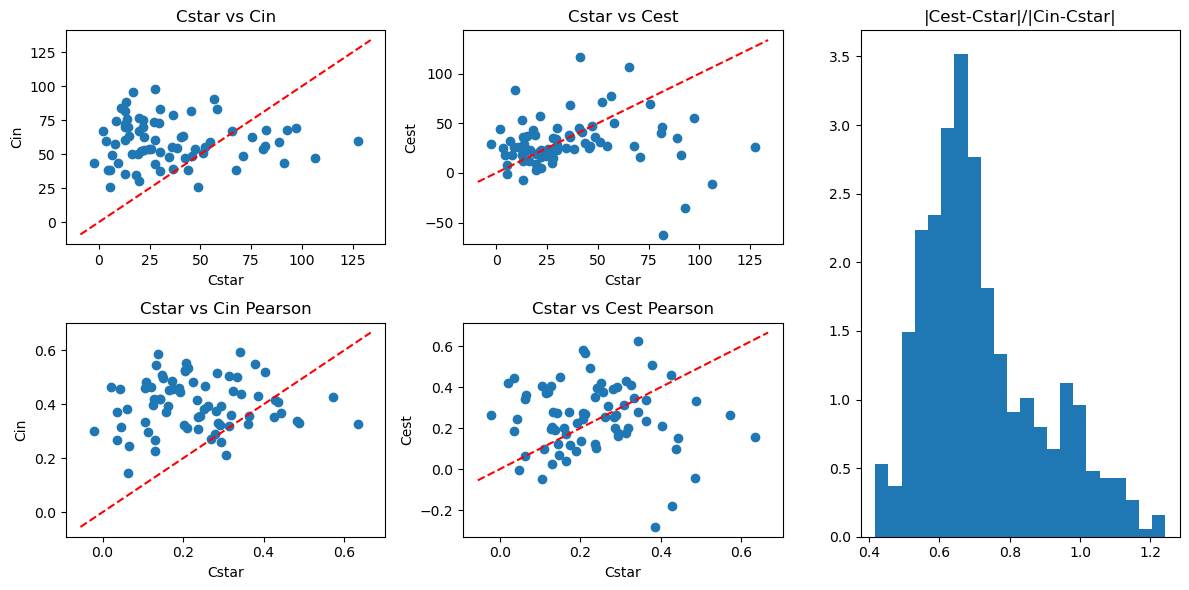

In [186]:
from matplotlib.gridspec import GridSpec
res = model.extract(seed=0, train=0, metric=metric, **extra_fields)
covs = res.vld
corrs = res.vld_corrs
 
is_square = covs.Cin.shape[0] == covs.Cin.shape[1]
fig = plt.figure(figsize=(12, 6))
if is_square:
    gs = GridSpec(2,4)
    # The first three columns of hte first row are Cin, Cstar, Cest
    # Those of the second row are the corresponding pearson correlations
    for i, ds in enumerate(["Cin", "Cstar", "Cest"]):
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(getattr(covs, ds))
        ax.set_title(ds)
        ax = fig.add_subplot(gs[1, i])
        ax.imshow(corrs[ds], vmin=0, vmax=1, cmap="bwr")
        ax.set_title(f"{ds} Pearson")
else:
    # Plot as a scatter of Cstar vs Cin, Cstar vs Cest
    gs = GridSpec(2, 3)
    for i, ds in enumerate(["Cin", "Cest"]):
        ax = fig.add_subplot(gs[0, i])
        ax.scatter(covs.Cstar.flatten(),getattr(covs, ds).flatten())
        ax.set_title(f"Cstar vs {ds}")
        ax.set_xlabel("Cstar")
        ax.set_ylabel(ds)
        xl = ax.get_xlim()
        ax.plot(xl, xl, ls="--", color="r")
        ax = fig.add_subplot(gs[1, i])
        ax.scatter(corrs["Cstar"].flatten(), corrs[ds].flatten())
        ax.set_title(f"Cstar vs {ds} Pearson")
        ax.set_xlabel("Cstar")
        ax.set_ylabel(f"{ds}")
        xl = ax.get_xlim()
        ax.plot(xl, xl, ls="--", color="r")
 
    
ax = fig.add_subplot(gs[:, -1])
ax.hist(vals, bins=int(np.sqrt(len(vals))), density=True)
ax.set_title("|Cest-Cstar|/|Cin-Cstar|")
tight_layout()